In [1]:
import pandas as pd

In [7]:
human = pd.read_csv("eval.csv")

,model,relevance_macro,clarity_macro,correctness_macro,total_macro
0,predictions_real6,2.800,2.933,2.533,8.267
1,predictions_real5,2.733,2.800,2.467,8.000
2,predictions_real4,2.733,2.867,2.333,7.933
3,predictions_real3,2.800,2.933,1.733,7.467
4,QWEN3_4B instruct base,2.200,2.400,1.600,6.200


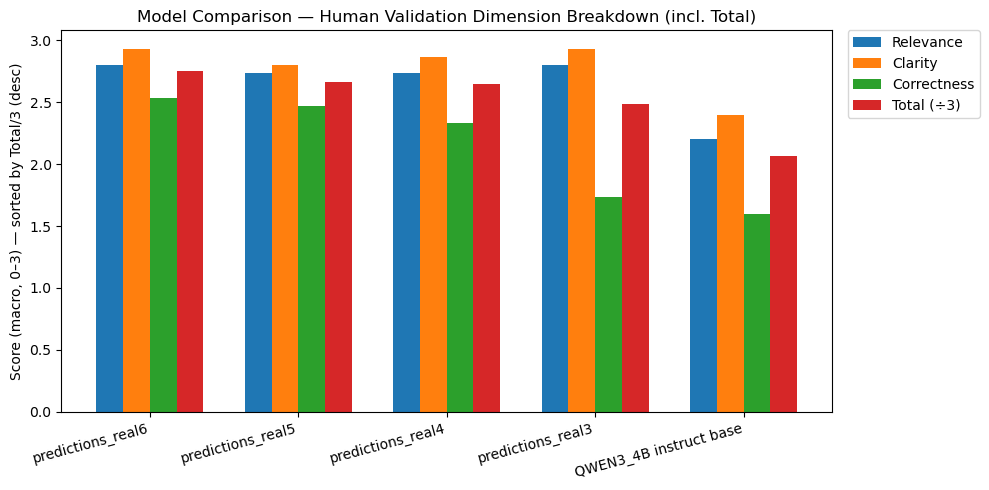

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert 'human' in globals(), "`human` DataFrame not found."
need = {"set_id","prompt_id","model","run","relevance","clarity","correctness","total"}
missing = need - set(human.columns)
assert not missing, f"`human` is missing columns: {missing}"

for c in ["relevance","clarity","correctness","total"]:
    human[c] = pd.to_numeric(human[c], errors="coerce")

# mean over runs
human_agg_prompt = (human
    .groupby(["set_id","prompt_id","model"], as_index=False)
    .agg(relevance_meanOverRuns=("relevance","mean"),
         clarity_meanOverRuns=("clarity","mean"),
         correctness_meanOverRuns=("correctness","mean"),
         total_meanOverRuns=("total","mean")))

# mean over prompts within each set
human_within_set = (human_agg_prompt
    .groupby(["set_id","model"], as_index=False)
    .agg(relevance_setMean=("relevance_meanOverRuns","mean"),
         clarity_setMean=("clarity_meanOverRuns","mean"),
         correctness_setMean=("correctness_meanOverRuns","mean"),
         total_setMean=("total_meanOverRuns","mean")))

# Macro
leaderboard_human = (human_within_set
    .groupby("model", as_index=False)
    .agg(relevance_macro=("relevance_setMean","mean"),
         clarity_macro=("clarity_setMean","mean"),
         correctness_macro=("correctness_setMean","mean"),
         total_macro=("total_setMean","mean"))
    .sort_values("total_macro", ascending=False)
    .reset_index(drop=True))

display(leaderboard_human.round(3))

# plot
label_map = {
    "predictions_real1": "QWEN3_4B instruct base",
    "predictions_real3": "predictions_real3",
    "predictions_real4": "predictions_real4",
    "predictions_real5": "predictions_real5",
    "predictions_real6": "predictions_real6",
}

dfp = leaderboard_human.copy()
dfp["label"] = dfp["model"].map(label_map).fillna(dfp["model"])

# sort
dfp["total_macro_scaled"] = dfp["total_macro"] / 3.0
dfp = dfp.sort_values("total_macro_scaled", ascending=False).reset_index(drop=True)
metrics = ["relevance_macro", "clarity_macro", "correctness_macro", "total_macro_scaled"]
metric_labels = ["Relevance", "Clarity", "Correctness", "Total (÷3)"]

x = np.arange(len(dfp))
width = 0.18  # 4 bars per group
offsets = (np.arange(len(metrics)) - (len(metrics)-1)/2) * width

plt.figure(figsize=(10,5))
for i, (mcol, mlabel) in enumerate(zip(metrics, metric_labels)):
    plt.bar(x + offsets[i], dfp[mcol], width=width, label=mlabel)

plt.xticks(x, dfp["label"], rotation=15, ha="right")
plt.ylabel("Score (macro, 0–3) — sorted by Total/3 (desc)")
plt.title("Model Comparison — Human Validation Dimension Breakdown (incl. Total)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
plt.tight_layout()
plt.show()
